# Business Understanding

## Project Domain

**Domain**: Education & Learning Analytic

**Sub-Domain**: Student Performance Prediction & Decision Support Systems

Deskripsi:
Sistem pendukung keputusan untuk prediksi kinerja siswa (Student Performance Prediction System) termasuk dalam bidang analitik pembelajaran (learning analytics) yang memanfaatkan data science dan machine learning untuk membantu institusi pendidikan memahami faktor-faktor yang mempengaruhi prestasi siswa. Sistem ini dapat digunakan untuk mengidentifikasi siswa yang berisiko rendah atau tinggi dalam pencapaian akademik, sehingga dapat membantu pengambilan keputusan terkait intervensi pendidikan.

## Problem Statements

Masalah yang Dihadapi:

 1. Kesenjangan Prestasi Akademik Berdasarkan Demografi
- Siswa dari latar belakang ras atau etnis tertentu mungkin menghadapi tantangan sistemik yang berdampak pada pencapaian akademik mereka.
- Hal ini dapat menyebabkan ketimpangan hasil belajar antara kelompok etnis yang berbeda.

 2. Pengaruh Latar Belakang Sosial-Ekonomi terhadap Kinerja Siswa
- Siswa yang menerima makan siang gratis atau bersubsidi cenderung berasal dari keluarga berpenghasilan rendah.
- Kondisi ini dapat memengaruhi konsentrasi, akses ke sumber belajar, dan pada akhirnya menurunkan performa akademik.

 3. Keterbatasan Akses ke Persiapan Ujian
- Tidak semua siswa memiliki kesempatan mengikuti kursus persiapan ujian karena keterbatasan biaya atau fasilitas.
- Hal ini dapat menyebabkan ketidakseimbangan dalam hasil tes standar antar siswa.

 4. Rendahnya Dukungan Pendidikan dari Orang Tua
- Orang tua dengan tingkat pendidikan rendah mungkin kurang mampu membantu anak mereka dalam hal akademik.
- Hal ini dapat berdampak negatif pada motivasi belajar dan prestasi siswa di berbagai mata pelajaran.

## Goals

Membangun sistem berbasis AI (Artificial Neural Network) yang dapat merekomendasikan performa belajar terbaik dengan menambah fitur berdasarkan:

 - Jam Tidur (Fitur yang akan memperlihatkan jam tidur seorang siswa yang bisa di bilang baik atau buruk nya, yang akan mempengaruhi performa belajar nya)
 - Berapa sering olahraga (Fitur yang akan memperlihatkan seberapa sering siswa olahraga melatih kebugaran untuk manfaat otak dan stamina tubuh)
 - Waktu jam belajar seorang siswa (Fitur yang akan memperlihatkan jam belajar siswa yang baik dan buruk nya untuk pengaruh otak siswa)

## Solution Statements

 - Machine Learning Model
Menggunakan Artificial Neural Network (ANN) untuk memprediksi kinerja akademik siswa berdasarkan data demografis dan sosial ekonomi. Model dilatih untuk mengklasifikasikan apakah seorang siswa berpotensi memiliki nilai rendah atau tinggi dengan akurasi tinggi (>90%).

- Aplikasi Web (Streamlit)
Membangun antarmuka pengguna sederhana untuk guru dan konselor sekolah agar dapat memasukkan informasi siswa dan mendapatkan prediksi performa akademik serta rekomendasi intervensi secara instan.

- Optimasi dengan TensorFlow Lite
Model dikonversi ke format TensorFlow Lite (TFLite) agar dapat dijalankan secara efisien pada perangkat dengan sumber daya terbatas, seperti tablet sekolah atau smartphone, sehingga dapat digunakan saat kunjungan rumah atau di sekolah terpencil.

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"azzaraalkhoiri","key":"2117eacc7f76ea5d465af270e5dd7e83"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d rkiattisak/student-performance-in-mathematics

Dataset URL: https://www.kaggle.com/datasets/rkiattisak/student-performance-in-mathematics
License(s): other


In [4]:
!mkdir student-performance-in-mathematics
!unzip student-performance-in-mathematics.zip -d student-performance-in-mathematics
!ls student-performance-in-mathematics

Archive:  student-performance-in-mathematics.zip
  inflating: student-performance-in-mathematics/exams.csv  
exams.csv


## Import Library yang dibutuhkan

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [38]:
df = pd.read_csv('/content/student-performance-in-mathematics/exams.csv')

In [39]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63
4,female,group D,associate's degree,standard,none,83,85,86


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


EDA 1 (HISPLOT)

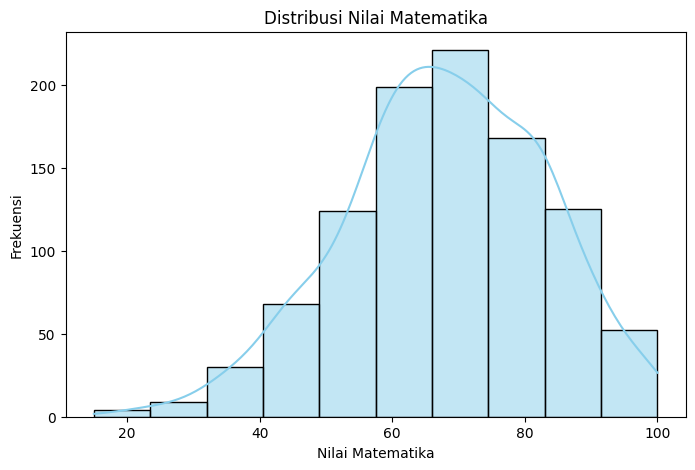

<Figure size 640x480 with 0 Axes>

In [41]:
plt.figure(figsize=(8, 5))
sns.histplot(df['math score'], bins=10, kde=True, color='skyblue')
plt.title('Distribusi Nilai Matematika')
plt.xlabel('Nilai Matematika')
plt.ylabel('Frekuensi')
plt.show()
plt.tight_layout()
plt.show()

EDA 2 (SUBPLOT)

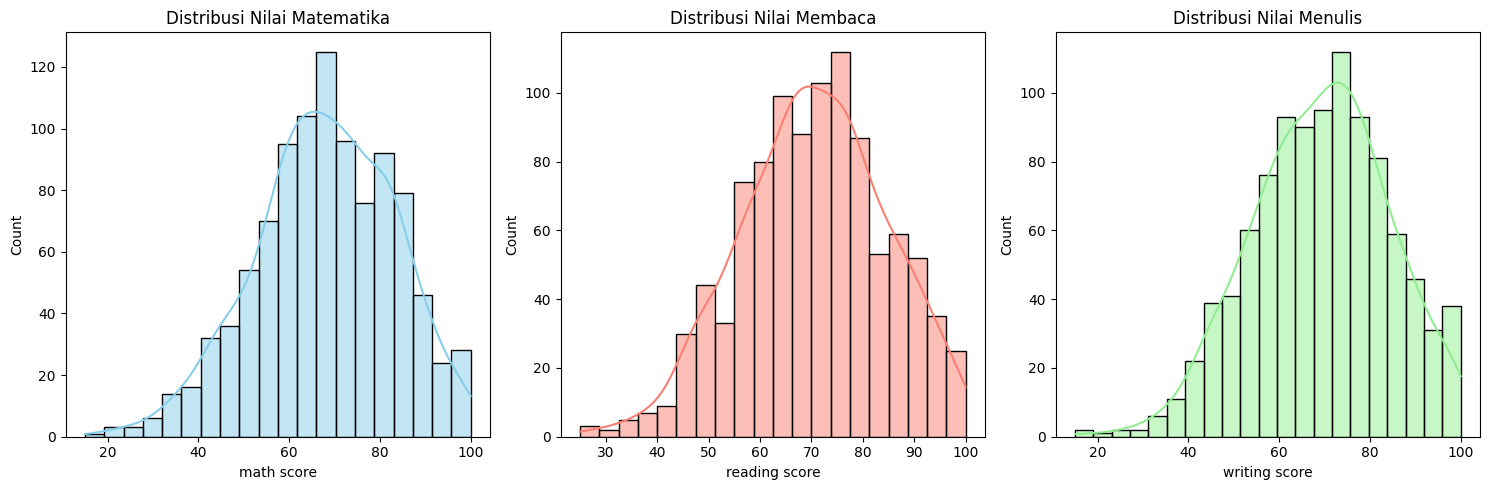

In [42]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['math score'], kde=True, color='skyblue')
plt.title('Distribusi Nilai Matematika')

plt.subplot(1, 3, 2)
sns.histplot(df['reading score'], kde=True, color='salmon')
plt.title('Distribusi Nilai Membaca')

plt.subplot(1, 3, 3)
sns.histplot(df['writing score'], kde=True, color='lightgreen')
plt.title('Distribusi Nilai Menulis')

plt.tight_layout()
plt.show()

EDA 3 (VIOLINPLOT)

<ipython-input-43-7c7228a9f586>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='race/ethnicity', y='lunch', data=df, palette='Set2')


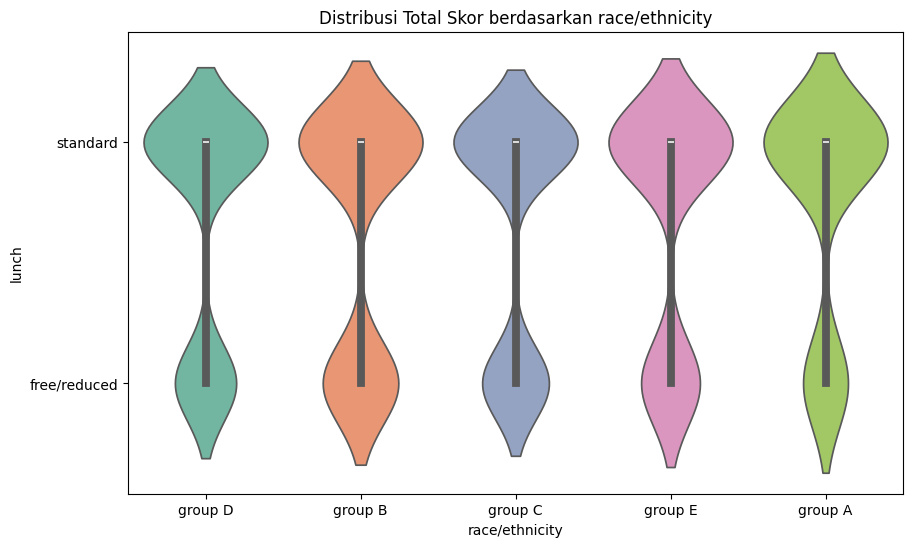

In [43]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='race/ethnicity', y='lunch', data=df, palette='Set2')
plt.title('Distribusi Total Skor berdasarkan race/ethnicity')
plt.show()

EDA 4 (GROUPED BAR CHART)

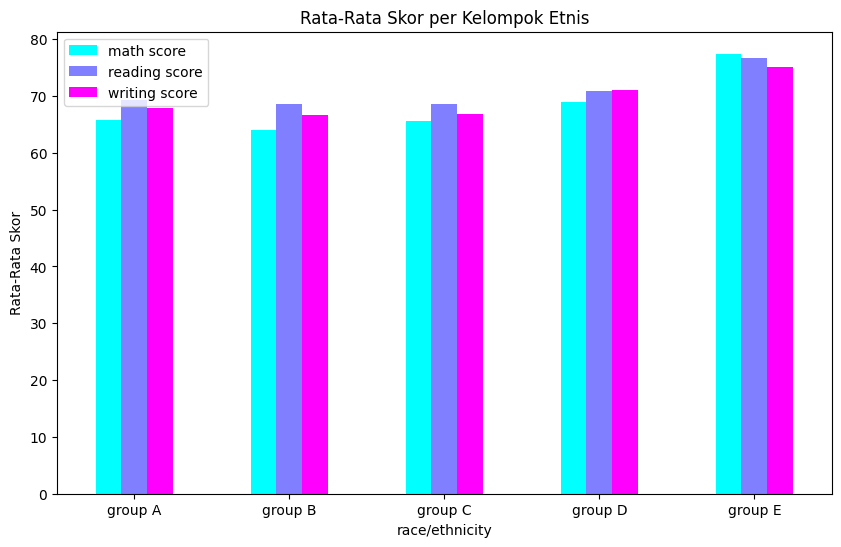

In [44]:
group_avg = df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean()
group_avg.plot(kind='bar', figsize=(10, 6), colormap='cool')
plt.title("Rata-Rata Skor per Kelompok Etnis")
plt.ylabel("Rata-Rata Skor")
plt.xticks(rotation=0)
plt.show()

EDA 1 (PAIRPLOT)

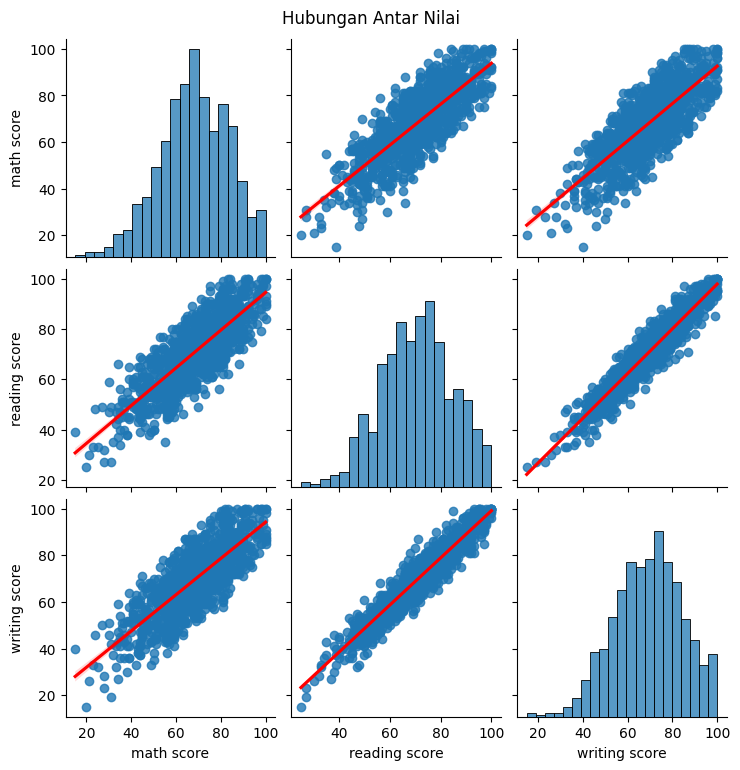

In [45]:
sns.pairplot(df[['math score', 'reading score', 'writing score']], kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle("Hubungan Antar Nilai", y=1.02)
plt.show()

# Data Preparation

In [46]:
# disini saya akan Mengubah fitur genderdengan nilai name=5, female=10
df['gender'] = np.random.choice(['Male', 'Female'], size=len(df))
df['gender'] = df['gender'].map({'Male': 5, 'Female': 10})

In [47]:
# Mengubah data pada fitur2 berikut
le_race = LabelEncoder()
le_parent_edu = LabelEncoder()
le_lunch = LabelEncoder()
le_test_prep = LabelEncoder()

In [48]:
df['race/ethnicity'] = le_race.fit_transform(df['race/ethnicity'])
df['parental level of education'] = le_parent_edu.fit_transform(df['parental level of education'])
df['lunch'] = le_lunch.fit_transform(df['lunch'])
df['test preparation course'] = le_test_prep.fit_transform(df['test preparation course'])

** Disini saya menambahkan fitur PERFORMANCE CATEGORY yang akhirnya akan menjadi Target**

In [49]:
# Menambah fitur performance category
def kategori_performance(row):
    avg = (row['math score'] + row['reading score'] + row['writing score']) / 3
    if avg >= 85:
        return 'Sangat Baik'
    elif avg >= 70:
        return 'Baik'
    elif avg >= 60:
        return 'Cukup'
    else:
        return 'Buruk'

df['performance_category'] = df.apply(kategori_performance, axis=1)

In [50]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,performance_category
0,5,3,4,1,0,59,70,78,Cukup
1,10,3,0,1,1,96,93,87,Sangat Baik
2,10,3,4,0,1,57,76,77,Baik
3,10,1,4,0,1,70,70,63,Cukup
4,10,3,0,1,1,83,85,86,Baik


In [52]:
# pisahkan fitur dan target
X = df.drop(columns=["performance_category"])
y = df["performance_category"]

In [53]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [54]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [57]:
# Membangun model
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [58]:
# compile model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [59]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,620 (45.39 KB)

 Trainable params: 11,620 (45.39 KB)

 Non-trainable params: 0 (0.00 B)

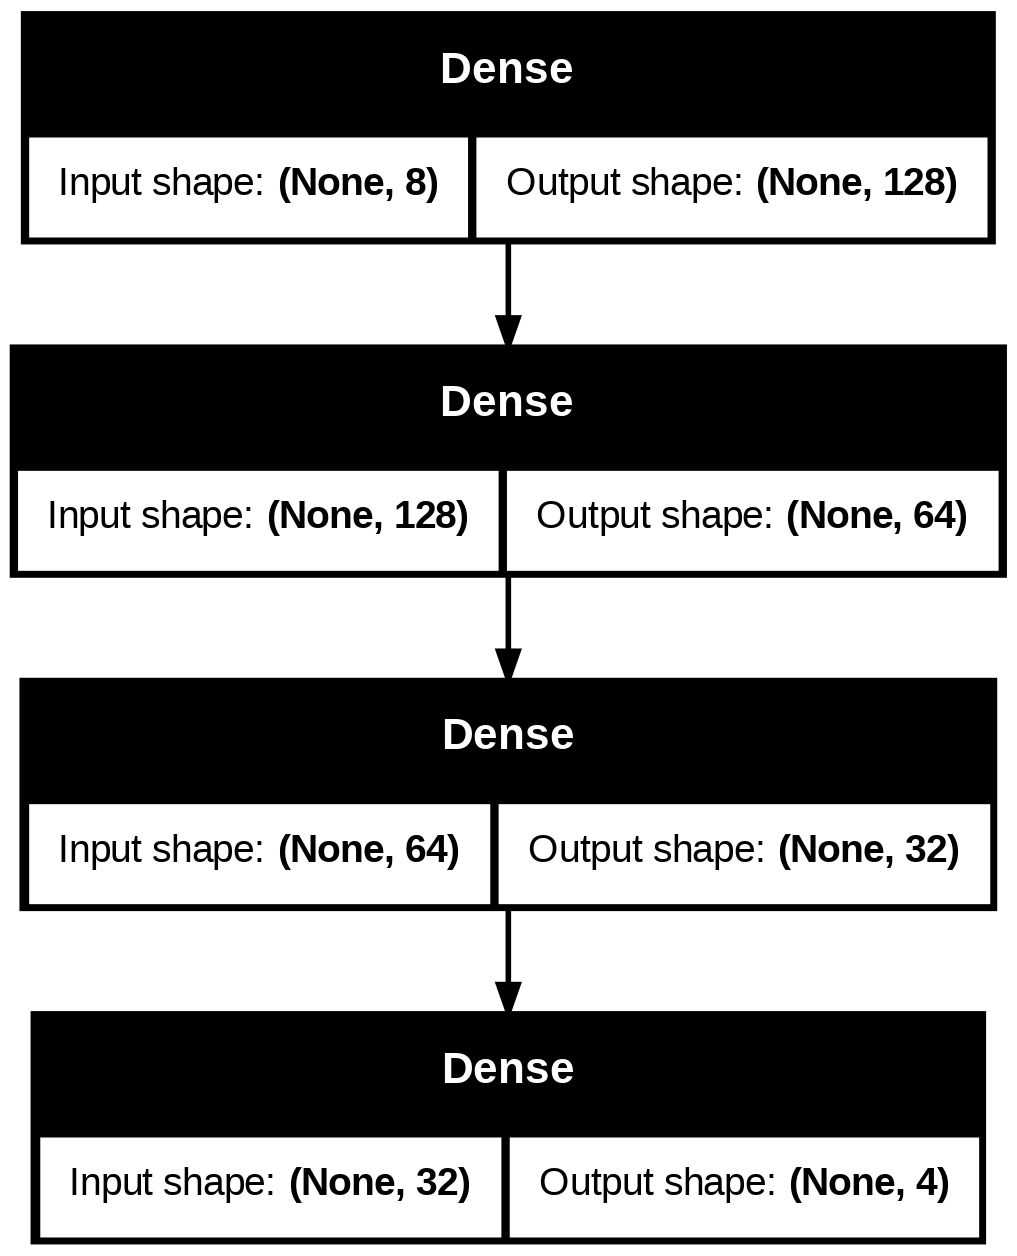

In [60]:
#plot arsitektur model
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [61]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3403 - loss: 1.3569 - val_accuracy: 0.4500 - val_loss: 1.2421
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5094 - loss: 1.1930 - val_accuracy: 0.4800 - val_loss: 1.0663
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6037 - loss: 0.9491 - val_accuracy: 0.6350 - val_loss: 0.8097
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6932 - loss: 0.7127 - val_accuracy: 0.8050 - val_loss: 0.5985
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8266 - loss: 0.5164 - val_accuracy: 0.8650 - val_loss: 0.4538
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8937 - loss: 0.3845 - val_accuracy: 0.9100 - val_loss: 0.3320
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9228 - loss: 0.2998 - val_accuracy: 0.8300 - val_loss: 0.4089
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8847 - loss: 0.3164 - val_accuracy: 0.9100 - val_loss

# Evaluation

In [62]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9737 - loss: 0.0829 
Akurasi Model: 0.9750
Loss Model: 0.0876


In [63]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

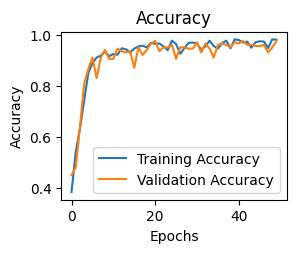

In [64]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

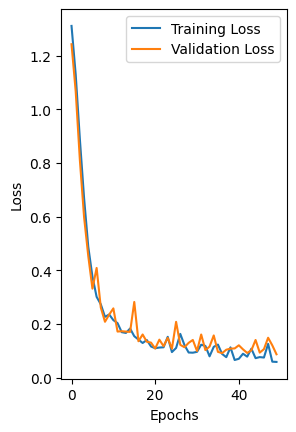

In [65]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


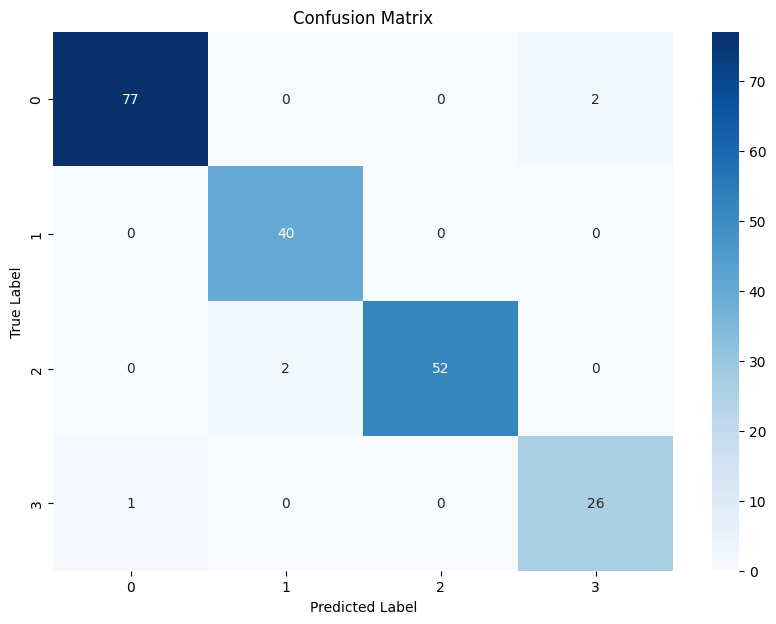

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        79
           1       0.95      1.00      0.98        40
           2       1.00      0.96      0.98        54
           3       0.93      0.96      0.95        27

    accuracy                           0.97       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200



In [66]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [67]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,performance_category
0,5,3,4,1,0,59,70,78,Cukup
1,10,3,0,1,1,96,93,87,Sangat Baik
2,10,3,4,0,1,57,76,77,Baik
3,10,1,4,0,1,70,70,63,Cukup
4,10,3,0,1,1,83,85,86,Baik
5,10,2,5,1,1,68,57,54,Buruk
6,10,4,0,1,1,82,83,80,Baik
7,5,1,5,1,1,46,61,58,Buruk
8,5,2,5,1,1,80,75,73,Baik
9,5,2,1,1,0,57,69,77,Cukup


In [68]:
sample_input = np.array([[10, 4 ,5, 0, 1,	57, 70, 63]])
sample_input_df = pd.DataFrame(sample_input)

In [69]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [70]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"PERFORMA BELAJAR MU ADALAH: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
PERFORMA BELAJAR MU ADALAH: Cukup


## Save Model

In [71]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('student-performance.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp78f5vu77'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138184959518928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138184959514128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138184959515664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138184959517008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138184871320976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138184871318864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138184871321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138184871322320: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [72]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']